# Week 11 — Wednesday (Jun 17, Remote): YOLO — You Only Look Once

## Learning Objectives
- Understand the YOLO paradigm: single-pass detection vs two-stage methods
- Implement YOLO grid encoding and bounding-box decoding from scratch
- Understand the YOLO multi-part loss function
- Trace the architecture evolution from YOLOv1 → YOLOv8
- Run YOLOv8 inference and interpret the output
- Visualise multi-scale detection heads

## Key Concepts
1. **Grid prediction** — divide image into S×S cells; each cell predicts B boxes + C classes
2. **Objectness score** — Pr(object) × IoU; confidence that a box contains an object
3. **Anchor boxes** — pre-defined aspect-ratio priors per grid cell
4. **Multi-scale heads** — detect at 3 scales (large/medium/small objects)
5. **YOLO loss** — localisation + objectness + classification, weighted sum
6. **YOLOv8** — anchor-free, decoupled head, task-aligned assigner

## Section 1: Setup

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
print('OpenCV:', cv2.__version__)

OpenCV: 4.13.0


## Section 2: YOLO Architecture Evolution

### The Core Idea
Two-stage detectors (R-CNN family) first **propose regions**, then classify them.
YOLO does everything in **one forward pass** — hence "You Only Look Once".

| Version | Year | Key Innovation |
|---------|------|----------------|
| **YOLOv1** | 2016 | Grid-based single-pass detection; unified loss |
| **YOLOv2** | 2017 | Anchor boxes, Batch Norm, multi-scale training, Darknet-19 |
| **YOLOv3** | 2018 | Darknet-53, 3-scale FPN-style head, binary cross-entropy class loss |
| **YOLOv4** | 2020 | CSPDarknet, PANet neck, Mosaic augmentation, CIoU loss |
| **YOLOv5** | 2020 | PyTorch rewrite, auto-anchor, Focus layer, TTA |
| **YOLOv6/7** | 2022 | Reparameterization, ELAN blocks, efficient heads |
| **YOLOv8** | 2023 | Anchor-free, decoupled head, task-aligned assigner, C2f block |

### Speed vs Accuracy Trade-off
```
Accuracy
  ^  Faster R-CNN ●
  |          YOLOv8-x ●
  |     YOLOv8-m ●
  |  YOLOv8-n ●
  └──────────────────► Speed (FPS)
```

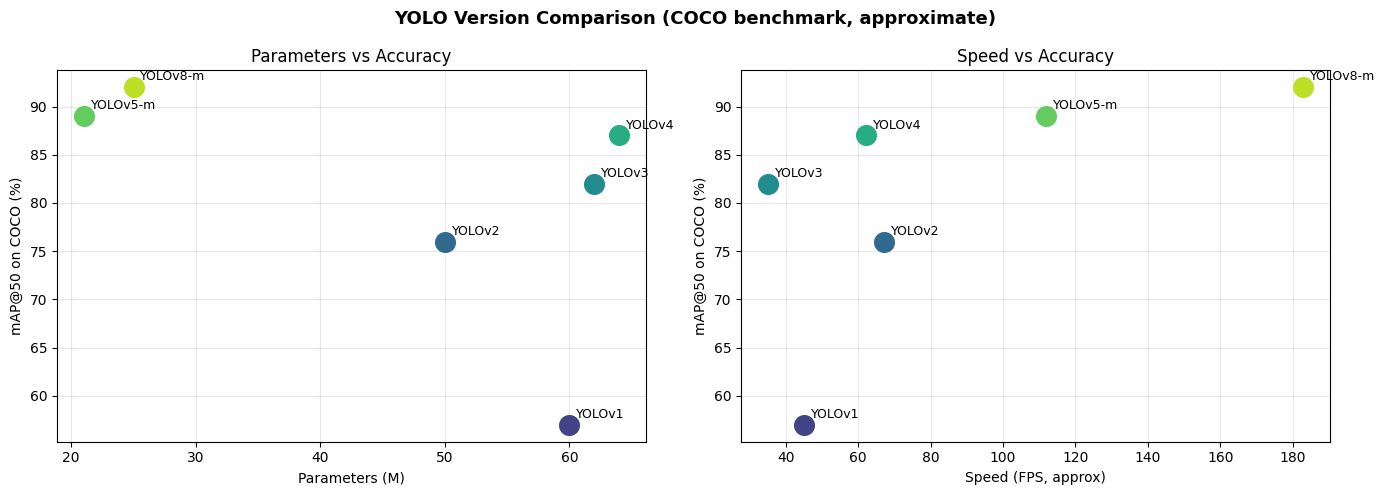

In [2]:
# Visualise YOLO evolution: parameter count vs mAP (approximate, COCO val)
versions = ['YOLOv1', 'YOLOv2', 'YOLOv3', 'YOLOv4', 'YOLOv5-m', 'YOLOv8-m']
params_M = [        60,      50,      62,      64,       21,         25]
map50    = [        57,      76,      82,      87,       89,         92]
fps      = [        45,      67,      35,      62,      112,        183]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(versions)))
for i, (v, p, m, f) in enumerate(zip(versions, params_M, map50, fps)):
    axes[0].scatter(p, m, s=200, color=colors[i], zorder=5)
    axes[0].annotate(v, (p, m), textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].set_xlabel('Parameters (M)')
axes[0].set_ylabel('mAP@50 on COCO (%)')
axes[0].set_title('Parameters vs Accuracy')
axes[0].grid(True, alpha=0.3)

for i, (v, f, m) in enumerate(zip(versions, fps, map50)):
    axes[1].scatter(f, m, s=200, color=colors[i], zorder=5)
    axes[1].annotate(v, (f, m), textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[1].set_xlabel('Speed (FPS, approx)')
axes[1].set_ylabel('mAP@50 on COCO (%)')
axes[1].set_title('Speed vs Accuracy')
axes[1].grid(True, alpha=0.3)

plt.suptitle('YOLO Version Comparison (COCO benchmark, approximate)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 3: YOLOv1 Grid Prediction — From Scratch

### How YOLOv1 Works
1. Divide input image into an **S × S grid** (e.g. 7×7)
2. Each grid cell predicts **B bounding boxes** (e.g. B=2)
3. Each box has 5 values: `[x, y, w, h, confidence]`
   - `(x, y)` — box centre **relative to the cell**
   - `(w, h)` — box size **relative to full image**
   - `confidence` — Pr(object) × IoU(pred, gt)
4. Each cell also predicts **C class probabilities** (shared across B boxes)

**Output tensor shape:** `S × S × (B×5 + C)`
For S=7, B=2, C=20 (VOC): `7 × 7 × 30`

### Responsible Cell Rule
The grid cell whose centre falls inside a ground-truth box is **responsible** for detecting that object.

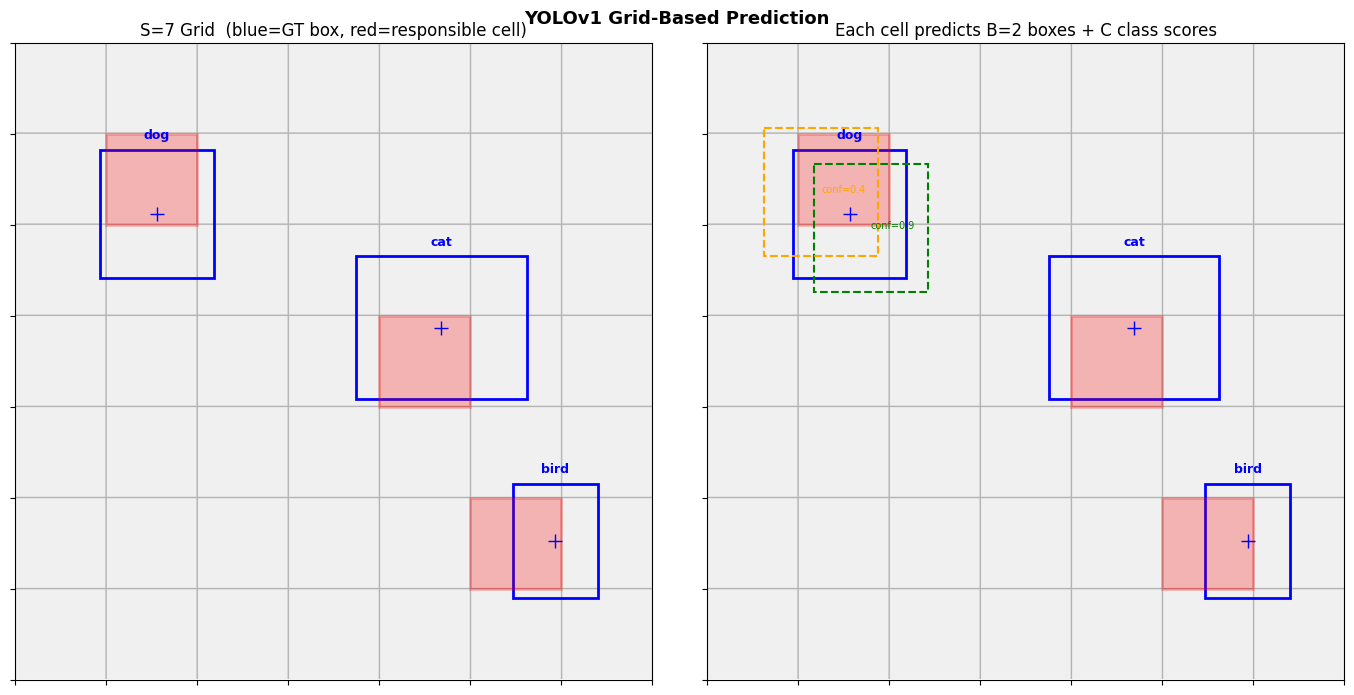

S=7: output tensor shape = 7 x 7 x 30  (B=2 boxes x 5 + C=20 classes)


In [3]:
def visualise_yolo_grid(img_h=448, img_w=448, S=7):
    """Draw the YOLO grid and show which cell is responsible for each GT box."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Synthetic ground-truth boxes [cx, cy, w, h] in pixel coords
    gt_boxes = [
        (100, 120, 80,  90,  'dog'),
        (300, 200, 120, 100, 'cat'),
        (380, 350, 60,  80,  'bird'),
    ]

    cell_w = img_w / S
    cell_h = img_h / S

    for ax_idx, ax in enumerate(axes):
        # White canvas
        canvas = np.ones((img_h, img_w, 3), dtype=np.uint8) * 240

        # Draw grid lines
        for i in range(1, S):
            cv2.line(canvas, (int(i*cell_w), 0), (int(i*cell_w), img_h), (180,180,180), 1)
            cv2.line(canvas, (0, int(i*cell_h)), (img_w, int(i*cell_h)), (180,180,180), 1)

        ax.imshow(canvas)

        for cx, cy, bw, bh, label in gt_boxes:
            # GT box
            rect = Rectangle((cx - bw/2, cy - bh/2), bw, bh,
                              linewidth=2, edgecolor='blue', facecolor='none')
            ax.add_patch(rect)
            ax.plot(cx, cy, 'b+', markersize=10)

            # Responsible cell
            cell_col = int(cx / cell_w)
            cell_row = int(cy / cell_h)
            resp_rect = Rectangle((cell_col * cell_w, cell_row * cell_h),
                                   cell_w, cell_h,
                                   linewidth=2, edgecolor='red',
                                   facecolor='red', alpha=0.25)
            ax.add_patch(resp_rect)
            ax.text(cx, cy - bh/2 - 8, label, color='blue',
                    fontsize=9, ha='center', fontweight='bold')

        ax.set_xlim(0, img_w)
        ax.set_ylim(img_h, 0)
        ax.set_xticks(np.arange(0, img_w+1, cell_w))
        ax.set_yticks(np.arange(0, img_h+1, cell_h))
        ax.tick_params(labelbottom=False, labelleft=False)
        ax.grid(False)

        if ax_idx == 0:
            ax.set_title(f'S={S} Grid  (blue=GT box, red=responsible cell)')
        else:
            ax.set_title('Each cell predicts B=2 boxes + C class scores')
            # Draw two example predicted boxes for the first GT
            for dx, dy, c in [(15, 10, 0.9), (-20, -15, 0.4)]:
                ex = Rectangle((gt_boxes[0][0] - gt_boxes[0][2]/2 + dx,
                                 gt_boxes[0][1] - gt_boxes[0][3]/2 + dy),
                                 gt_boxes[0][2], gt_boxes[0][3],
                                 linewidth=1.5,
                                 edgecolor='green' if c > 0.5 else 'orange',
                                 facecolor='none', linestyle='--')
                ax.add_patch(ex)
                ax.text(gt_boxes[0][0] + dx, gt_boxes[0][1] + dy,
                        f'conf={c}', fontsize=7, color='green' if c > 0.5 else 'orange')

    plt.suptitle('YOLOv1 Grid-Based Prediction', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualise_yolo_grid(S=7)
print('S=7: output tensor shape = 7 x 7 x 30  (B=2 boxes x 5 + C=20 classes)')

## Section 4: Bounding-Box Encoding & Decoding

YOLO predicts box coordinates **relative to the grid cell**, not absolute pixels.

| Value | What it means | Range |
|-------|--------------|-------|
| `tx, ty` | Box centre offset from cell top-left | 0 → 1 |
| `tw, th` | Log-scale offset from anchor size | unconstrained |
| `to` | Objectness logit | sigmoid → 0–1 |

**Decode (YOLOv3+ with anchors):**
```
bx = sigmoid(tx) + cx          # cx = column index of cell
by = sigmoid(ty) + cy          # cy = row index of cell
bw = anchor_w * exp(tw)
bh = anchor_h * exp(th)
```

In [4]:
def encode_box(gt_cx, gt_cy, gt_w, gt_h, anchor_w, anchor_h, cell_x, cell_y):
    """Encode a GT box into YOLO prediction targets (YOLOv3 style)."""
    tx = gt_cx - cell_x               # offset from cell top-left (already in cell units)
    ty = gt_cy - cell_y
    tw = np.log(gt_w  / anchor_w + 1e-9)
    th = np.log(gt_h  / anchor_h + 1e-9)
    return tx, ty, tw, th

def decode_box(tx, ty, tw, th, anchor_w, anchor_h, cell_x, cell_y, stride):
    """Decode YOLO prediction back to absolute pixel coordinates."""
    bx = (1 / (1 + np.exp(-tx)) + cell_x) * stride
    by = (1 / (1 + np.exp(-ty)) + cell_y) * stride
    bw = anchor_w * np.exp(tw)
    bh = anchor_h * np.exp(th)
    return bx, by, bw, bh

# Example: 416x416 image, stride=32 -> 13x13 grid
STRIDE = 32
GRID   = 416 // STRIDE   # 13

# Anchor (in pixels) — typical medium-scale anchor
anchor_w, anchor_h = 116, 90

# GT box in pixels
gt_cx, gt_cy = 200, 180
gt_w,  gt_h  = 120, 100

# Responsible cell
cell_x = int(gt_cx / STRIDE)
cell_y = int(gt_cy / STRIDE)

tx, ty, tw, th = encode_box(gt_cx/STRIDE, gt_cy/STRIDE, gt_w, gt_h,
                            anchor_w, anchor_h, cell_x, cell_y)
print('Encoded targets:')
print(f'  tx={tx:.4f}  ty={ty:.4f}  tw={tw:.4f}  th={th:.4f}')

# Decode back
bx, by, bw, bh = decode_box(tx, ty, tw, th, anchor_w, anchor_h, cell_x, cell_y, STRIDE)
print('\nDecoded prediction (pixels):')
print(f'  bx={bx:.1f}  by={by:.1f}  bw={bw:.1f}  bh={bh:.1f}')
print(f'\nGround truth (pixels):')
print(f'  cx={gt_cx}   cy={gt_cy}   w={gt_w}    h={gt_h}')
print(f'\nReconstruction error: dx={abs(bx-gt_cx):.4f}  dy={abs(by-gt_cy):.4f}')

Encoded targets:
  tx=0.2500  ty=0.6250  tw=0.0339  th=0.1054

Decoded prediction (pixels):
  bx=210.0  by=180.8  bw=120.0  bh=100.0

Ground truth (pixels):
  cx=200   cy=180   w=120    h=100

Reconstruction error: dx=9.9896  dy=0.8434


## Section 5: YOLO Loss Function

YOLOv1 used a **weighted multi-part MSE loss**:

$$\mathcal{L} = \lambda_{\text{coord}} \sum_{ij} \mathbf{1}_{ij}^{\text{obj}} \left[(x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2\right]$$
$$+ \lambda_{\text{coord}} \sum_{ij} \mathbf{1}_{ij}^{\text{obj}} \left[(\sqrt{w_i} - \sqrt{\hat{w}_i})^2 + (\sqrt{h_i} - \sqrt{\hat{h}_i})^2\right]$$
$$+ \sum_{ij} \mathbf{1}_{ij}^{\text{obj}} (C_i - \hat{C}_i)^2$$
$$+ \lambda_{\text{noobj}} \sum_{ij} \mathbf{1}_{ij}^{\text{noobj}} (C_i - \hat{C}_i)^2$$
$$+ \sum_i \mathbf{1}_i^{\text{obj}} \sum_c (p_i(c) - \hat{p}_i(c))^2$$

**Key design decisions:**
- `λ_coord = 5` — up-weight localisation loss (more important than confidence)
- `λ_noobj = 0.5` — down-weight empty cells (most cells have no object)
- Square root of w/h — penalises errors in small boxes more

**Modern YOLO (v3+) uses:**
- Binary cross-entropy for objectness and class scores
- CIoU / DIoU loss for box regression (better than MSE on coordinates)

In [5]:
def yolo_coord_loss(pred_xy, pred_wh, gt_xy, gt_wh, lambda_coord=5.0):
    """YOLOv1-style coordinate loss."""
    xy_loss = lambda_coord * np.sum((pred_xy - gt_xy) ** 2)
    # Square root trick: penalise small-box errors more
    wh_loss = lambda_coord * np.sum((np.sqrt(np.abs(pred_wh)) - np.sqrt(np.abs(gt_wh))) ** 2)
    return xy_loss, wh_loss

def binary_cross_entropy(pred, target, eps=1e-7):
    pred = np.clip(pred, eps, 1 - eps)
    return -np.mean(target * np.log(pred) + (1 - target) * np.log(1 - pred))

def ciou_loss(pred_box, gt_box):
    """Complete IoU loss — penalises centre distance + aspect ratio."""
    px, py, pw, ph = pred_box
    gx, gy, gw, gh = gt_box

    # Intersection
    ix1 = max(px - pw/2, gx - gw/2);  ix2 = min(px + pw/2, gx + gw/2)
    iy1 = max(py - ph/2, gy - gh/2);  iy2 = min(py + ph/2, gy + gh/2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = pw*ph + gw*gh - inter + 1e-7
    iou   = inter / union

    # Centre distance
    c2 = (max(px+pw/2, gx+gw/2) - min(px-pw/2, gx-gw/2))**2 + \
         (max(py+ph/2, gy+gh/2) - min(py-ph/2, gy-gh/2))**2 + 1e-7
    d2 = (px - gx)**2 + (py - gy)**2

    # Aspect ratio consistency
    v = (4 / np.pi**2) * (np.arctan(gw/(gh+1e-7)) - np.arctan(pw/(ph+1e-7)))**2
    alpha = v / (1 - iou + v + 1e-7)

    ciou = iou - d2/c2 - alpha*v
    return 1 - ciou

# ── Demo ──────────────────────────────────────────────────────────────────────
gt   = np.array([200.0, 180.0, 120.0, 100.0])
pred = np.array([205.0, 175.0, 118.0,  97.0])   # close prediction
pred_far = np.array([240.0, 210.0, 80.0, 60.0]) # poor prediction

xy_l, wh_l = yolo_coord_loss(pred[:2], pred[2:], gt[:2], gt[2:])
print(f'YOLOv1 coord loss (good pred): xy={xy_l:.2f}  wh={wh_l:.2f}  total={xy_l+wh_l:.2f}')

xy_l2, wh_l2 = yolo_coord_loss(pred_far[:2], pred_far[2:], gt[:2], gt[2:])
print(f'YOLOv1 coord loss (poor pred): xy={xy_l2:.2f}  wh={wh_l2:.2f}  total={xy_l2+wh_l2:.2f}')

ciou_good = ciou_loss(pred, gt)
ciou_poor = ciou_loss(pred_far, gt)
print(f'\nCIoU loss (good pred): {ciou_good:.4f}')
print(f'CIoU loss (poor pred): {ciou_poor:.4f}')

# Objectness BCE
obj_conf  = np.array([0.9, 0.85, 0.1, 0.05])  # predicted confidence
obj_gt    = np.array([1.0, 1.0,  0.0, 0.0 ])  # GT objectness
print(f'\nObjectness BCE loss: {binary_cross_entropy(obj_conf, obj_gt):.4f}')

YOLOv1 coord loss (good pred): xy=250.00  wh=0.16  total=250.16
YOLOv1 coord loss (poor pred): xy=12500.00  wh=45.61  total=12545.61

CIoU loss (good pred): 0.1683
CIoU loss (poor pred): 0.8615

Objectness BCE loss: 0.1061


## Section 6: Multi-Scale Detection Heads (YOLOv3+)

YOLOv3 introduced **3 detection scales** — each targeting different object sizes:

| Scale | Grid | Stride | Targets | Anchor example (px) |
|-------|------|--------|---------|--------------------|
| Large objects  | 13×13 | 32 | Objects > 96 px | (116,90), (156,198), (373,326) |
| Medium objects | 26×26 | 16 | Objects 48–96 px | (30,61), (62,45), (59,119) |
| Small objects  | 52×52 | 8  | Objects < 48 px | (10,13), (16,30), (33,23) |

Each scale uses **3 anchors**, producing output: `Grid × Grid × 3 × (5 + C)`

**Feature Pyramid Network (FPN)** style:
```
Backbone (Darknet-53)
   └─ large feature map  (52×52)  ──► small  object head
   └─ medium feature map (26×26)  ──► medium object head  
   └─ small  feature map (13×13)  ──► large  object head
```
Features from deeper layers are **upsampled and concatenated** with shallower layers
so each head benefits from both semantic depth and spatial detail.

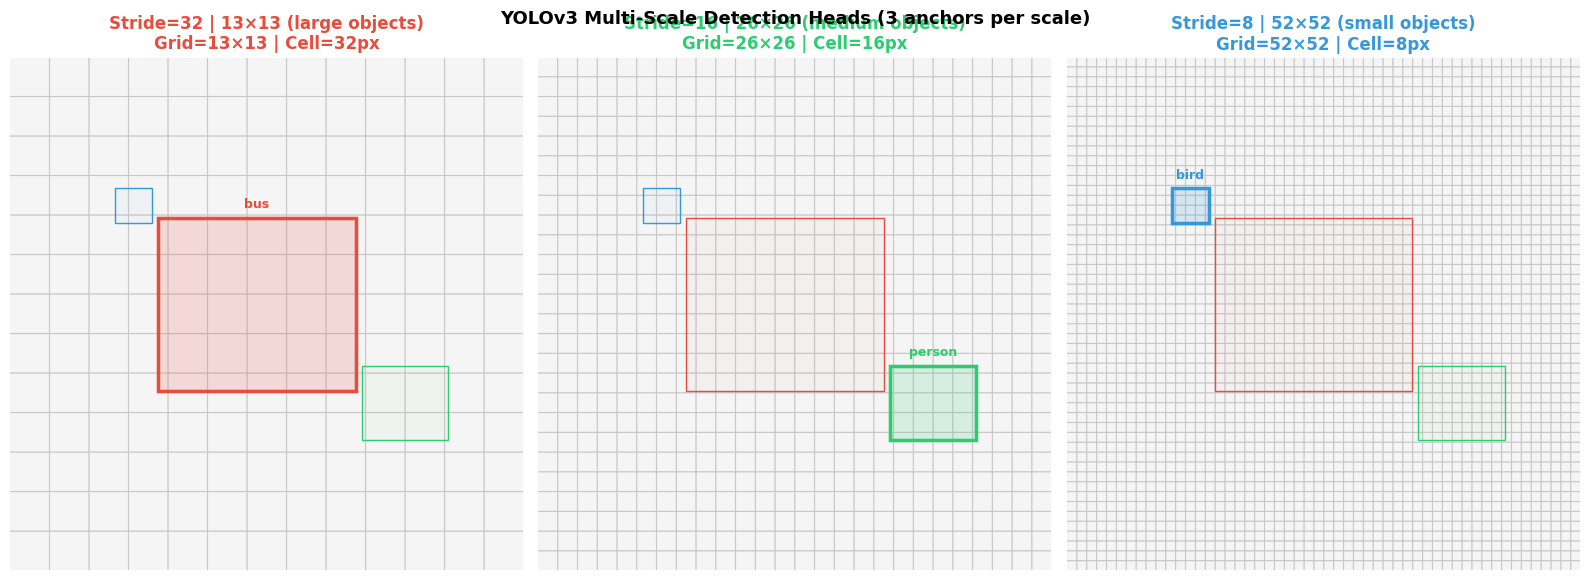

Total predictions per image (COCO 80 classes):
  13x13 grid: 13x13x3 =   507 boxes
  26x26 grid: 26x26x3 =  2028 boxes
  52x52 grid: 52x52x3 =  8112 boxes
  Total: 10647 candidate boxes


In [6]:
def visualise_multiscale(img_size=416):
    strides = [32, 16, 8]
    grids   = [img_size // s for s in strides]
    colors  = ['#e74c3c', '#2ecc71', '#3498db']  # large, medium, small
    labels  = ['13×13 (large objects)', '26×26 (medium objects)', '52×52 (small objects)']

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))

    # Synthetic objects of different sizes
    objects = [
        (200, 200, 160, 140, 'bus',    0),   # large
        (320, 280,  70,  60, 'person', 1),   # medium
        (100, 120,  30,  28, 'bird',   2),   # small
    ]

    for ax_idx, (ax, stride, grid, color, lbl) in enumerate(
            zip(axes, strides, grids, colors, labels)):
        canvas = np.ones((img_size, img_size, 3), dtype=np.uint8) * 245
        cell   = img_size // grid

        # Grid lines
        for i in range(1, grid):
            cv2.line(canvas, (i*cell, 0), (i*cell, img_size), (200,200,200), 1)
            cv2.line(canvas, (0, i*cell), (img_size, i*cell), (200,200,200), 1)

        ax.imshow(canvas)

        for cx, cy, bw, bh, name, scale_idx in objects:
            ec = colors[scale_idx]
            alpha = 0.8 if scale_idx == ax_idx else 0.15
            lw    = 2.5  if scale_idx == ax_idx else 1.0
            rect  = Rectangle((cx-bw/2, cy-bh/2), bw, bh,
                               linewidth=lw, edgecolor=ec,
                               facecolor=ec, alpha=alpha*0.2)
            border = Rectangle((cx-bw/2, cy-bh/2), bw, bh,
                                linewidth=lw, edgecolor=ec, facecolor='none')
            ax.add_patch(rect)
            ax.add_patch(border)
            if scale_idx == ax_idx:
                ax.text(cx, cy-bh/2-8, name, ha='center',
                        color=ec, fontsize=9, fontweight='bold')

        ax.set_xlim(0, img_size); ax.set_ylim(img_size, 0)
        ax.set_title(f'Stride={stride} | {lbl}\n'
                     f'Grid={grid}×{grid} | Cell={cell}px',
                     color=color, fontweight='bold')
        ax.axis('off')

    plt.suptitle('YOLOv3 Multi-Scale Detection Heads (3 anchors per scale)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualise_multiscale()
print('Total predictions per image (COCO 80 classes):')
for g, a in [(13, 3), (26, 3), (52, 3)]:
    preds = g * g * a
    print(f'  {g}x{g} grid: {g}x{g}x{a} = {preds:5d} boxes')
print(f'  Total: {13*13*3 + 26*26*3 + 52*52*3} candidate boxes')

## Section 7: Anchor-Free Detection (YOLOv8)

YOLOv8 drops anchor boxes entirely — a key architectural shift:

| | Anchor-based (v3/v4/v5) | Anchor-free (v8) |
|--|------------------------|------------------|
| **Box prediction** | Offset from anchor | Direct centre + size |
| **Assignment** | IoU with anchors | Task-Aligned Assigner |
| **Head** | Coupled (cls + box) | Decoupled heads |
| **Tuning** | Anchor clustering needed | No anchor tuning |

### Task-Aligned Assigner (TAL)
Assigns GT boxes to prediction cells using a combined score:

$$t = s^\alpha \cdot u^\beta$$

where `s` = classification score, `u` = IoU with GT, `α=0.5`, `β=6`.
Top-k cells (k=10 by default) are selected as positive anchors per GT.

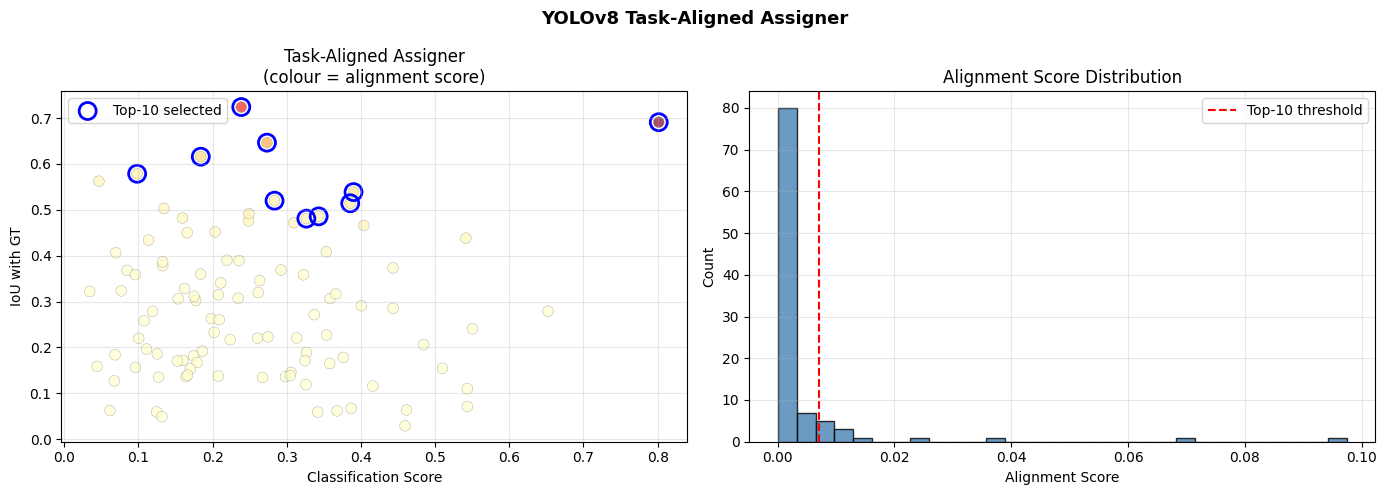

Top-10 selected indices: [67 93 13 89 21 55 96 29 57 17]
Their alignment scores : [0.0974 0.0703 0.0381 0.0234 0.0153 0.0118 0.0115 0.0105 0.0077 0.0071]


In [7]:
def task_aligned_assigner(pred_scores, pred_ious, alpha=0.5, beta=6.0, topk=10):
    """Simplified TAL: score each prediction by classification * IoU."""
    # Combined alignment metric
    alignment = (pred_scores ** alpha) * (pred_ious ** beta)

    # Select top-k predictions
    topk_idx = np.argsort(alignment)[::-1][:topk]
    return topk_idx, alignment

# Simulate 100 candidate predictions for one GT box
np.random.seed(42)
N = 100
pred_scores = np.random.beta(2, 5, N)   # classification confidence
pred_ious   = np.random.beta(2, 5, N)   # IoU with GT

topk_idx, alignment = task_aligned_assigner(pred_scores, pred_ious, topk=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pred_scores, pred_ious, c=alignment, cmap='YlOrRd',
                s=60, alpha=0.7, edgecolors='grey', linewidths=0.3)
axes[0].scatter(pred_scores[topk_idx], pred_ious[topk_idx],
                s=150, edgecolors='blue', facecolors='none', linewidths=2,
                label=f'Top-{len(topk_idx)} selected')
axes[0].set_xlabel('Classification Score')
axes[0].set_ylabel('IoU with GT')
axes[0].set_title('Task-Aligned Assigner\n(colour = alignment score)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(alignment, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(alignment[topk_idx[-1]], color='red', linestyle='--',
                label=f'Top-{len(topk_idx)} threshold')
axes[1].set_xlabel('Alignment Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Alignment Score Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('YOLOv8 Task-Aligned Assigner', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Top-10 selected indices: {topk_idx}')
print(f'Their alignment scores : {alignment[topk_idx].round(4)}')

## Section 8: NMS on YOLO Output

After decoding all grid predictions, thousands of boxes remain.
**Non-Maximum Suppression (NMS)** removes duplicates:

1. Filter boxes below confidence threshold (e.g. 0.25)
2. Sort remaining boxes by confidence
3. Keep the highest-confidence box
4. Remove all boxes that overlap it by IoU > threshold (e.g. 0.45)
5. Repeat for the next remaining box

YOLOv8 uses **class-specific NMS** — step 3–4 is applied per class separately.

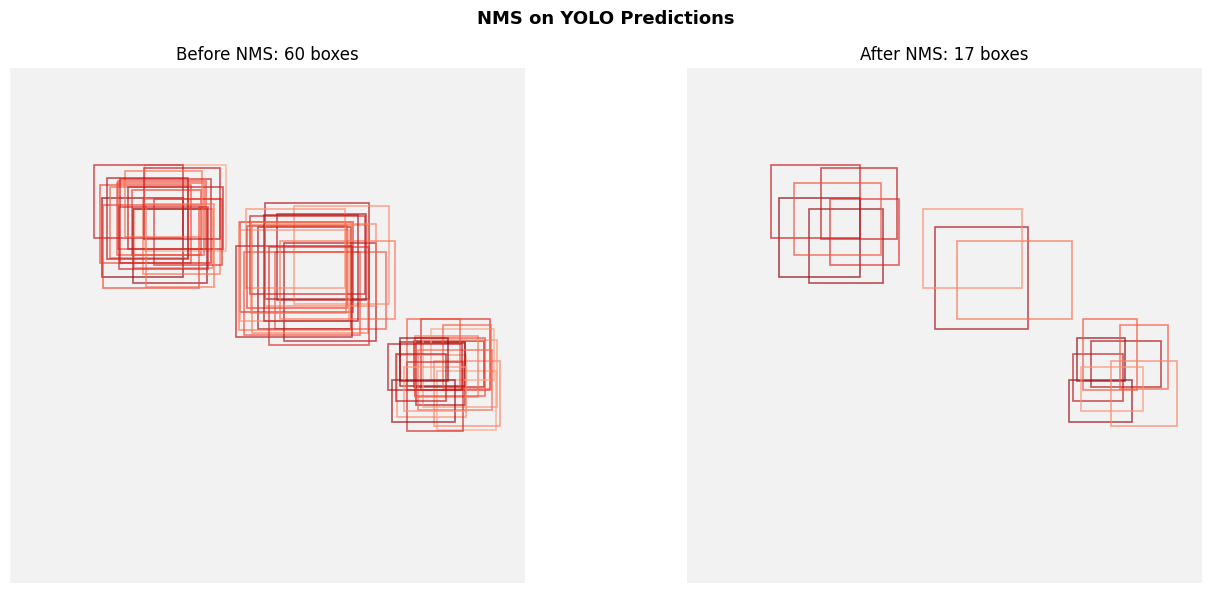

Before NMS : 60 boxes
After  NMS : 17 boxes (kept: [np.int64(0), np.int64(58), np.int64(56), np.int64(4), np.int64(24), np.int64(46), np.int64(59), np.int64(14), np.int64(11), np.int64(12), np.int64(10), np.int64(54), np.int64(52), np.int64(33), np.int64(43), np.int64(29), np.int64(57)])


In [8]:
def compute_iou_batch(box, boxes):
    """IoU between one box and an array of boxes. Format: [cx, cy, w, h]."""
    # Convert to x1y1x2y2
    b_x1, b_y1 = box[0]-box[2]/2, box[1]-box[3]/2
    b_x2, b_y2 = box[0]+box[2]/2, box[1]+box[3]/2
    x1 = boxes[:,0]-boxes[:,2]/2;  y1 = boxes[:,1]-boxes[:,3]/2
    x2 = boxes[:,0]+boxes[:,2]/2;  y2 = boxes[:,1]+boxes[:,3]/2

    ix1 = np.maximum(b_x1, x1);  iy1 = np.maximum(b_y1, y1)
    ix2 = np.minimum(b_x2, x2);  iy2 = np.minimum(b_y2, y2)
    inter = np.maximum(0, ix2-ix1) * np.maximum(0, iy2-iy1)
    union = box[2]*box[3] + boxes[:,2]*boxes[:,3] - inter + 1e-7
    return inter / union

def nms(boxes, scores, iou_thresh=0.45, conf_thresh=0.25):
    """Standard NMS. boxes: Nx4 [cx,cy,w,h], scores: N."""
    mask  = scores >= conf_thresh
    boxes, scores = boxes[mask], scores[mask]
    if len(boxes) == 0:
        return np.array([])

    order   = np.argsort(scores)[::-1]
    keep    = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        if len(order) == 1:
            break
        ious  = compute_iou_batch(boxes[i], boxes[order[1:]])
        order = order[1:][ious < iou_thresh]
    return keep

# Simulate YOLO output: many overlapping boxes around 3 objects
np.random.seed(7)
gt_obj = [(150, 150, 80, 70), (300, 200, 100, 90), (420, 300, 60, 55)]
all_boxes, all_scores = [], []
for cx, cy, w, h in gt_obj:
    for _ in range(20):
        dx, dy = np.random.uniform(-25, 25, 2)
        dw, dh = np.random.uniform(-15, 15, 2)
        all_boxes.append([cx+dx, cy+dy, w+dw, h+dh])
        all_scores.append(np.random.uniform(0.3, 0.95))

all_boxes  = np.array(all_boxes)
all_scores = np.array(all_scores)

kept_idx = nms(all_boxes, all_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
IMG_SIZE = 500

for ax_idx, ax in enumerate(axes):
    canvas = np.ones((IMG_SIZE, IMG_SIZE, 3)) * 0.95
    ax.imshow(canvas, extent=[0, IMG_SIZE, IMG_SIZE, 0])

    draw_boxes = all_boxes if ax_idx == 0 else all_boxes[kept_idx]
    draw_scores = all_scores if ax_idx == 0 else all_scores[kept_idx]

    for (cx, cy, w, h), sc in zip(draw_boxes, draw_scores):
        col = plt.cm.Reds(sc)
        rect = Rectangle((cx-w/2, cy-h/2), w, h,
                          linewidth=1.2, edgecolor=col, facecolor='none', alpha=0.7)
        ax.add_patch(rect)

    ax.set_xlim(0, IMG_SIZE); ax.set_ylim(IMG_SIZE, 0)
    ax.set_title(f'Before NMS: {len(all_boxes)} boxes' if ax_idx == 0
                 else f'After NMS: {len(kept_idx)} boxes')
    ax.axis('off')

plt.suptitle('NMS on YOLO Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Before NMS : {len(all_boxes)} boxes')
print(f'After  NMS : {len(kept_idx)} boxes (kept: {kept_idx})')

## Section 9: YOLOv8 Inference (Ultralytics)

The Ultralytics `ultralytics` package provides a clean API for YOLOv8 inference,
training, and export. It abstracts the full pipeline:
pre-process → forward pass → NMS → annotated output.

```python
from ultralytics import YOLO
model = YOLO('yolov8n.pt')      # nano — fastest, ~3M params
results = model('image.jpg')    # inference
```

**Model size variants:**

| Suffix | Size | mAP50-95 | Speed (ms) |
|--------|------|----------|------------|
| n      | Nano   | 37.3 | 1.6 |
| s      | Small  | 44.9 | 2.3 |
| m      | Medium | 50.2 | 5.1 |
| l      | Large  | 52.9 | 8.2 |
| x      | XLarge | 53.9 | 13.7 |

In [9]:
# Check if ultralytics is available
try:
    from ultralytics import YOLO
    HAS_ULTRALYTICS = True
    print('ultralytics available')
except ImportError:
    HAS_ULTRALYTICS = False
    print('ultralytics not installed. Run: pip install ultralytics')
    print('Showing YOLOv8 output structure demo instead.')

if HAS_ULTRALYTICS:
    # Load YOLOv8 nano (downloads weights ~6 MB on first run)
    model = YOLO('yolov8n.pt')

    # Create a synthetic test image
    test_img = np.zeros((640, 640, 3), dtype=np.uint8) + 200
    cv2.rectangle(test_img, (100, 150), (250, 380), (50,  50, 200), -1)  # blue rect
    cv2.circle(test_img,    (480, 320), 80,          (50, 200,  50), -1)  # green circle
    cv2.imwrite('_yolo_test.jpg', test_img)

    results = model('_yolo_test.jpg', verbose=False)
    r = results[0]

    print(f'Detections: {len(r.boxes)}')
    print(f'Classes   : {r.names}')
    if len(r.boxes) > 0:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            xyxy   = box.xyxy[0].tolist()
            print(f'  {r.names[cls_id]:15s} conf={conf:.2f}  box={[round(v,1) for v in xyxy]}')
    else:
        print('  (no objects detected in synthetic image — expected for random shapes)')

    import os; os.remove('_yolo_test.jpg')

else:
    # Show the result tensor structure without running inference
    print('\nYOLOv8 output structure for a 640x640 image (80 COCO classes):')
    print('  raw output shape: (1, 84, 8400)')
    print('  84 = 4 (box) + 80 (class scores)')
    print('  8400 = 80*80 + 40*40 + 20*20  (3 scales collapsed)')
    print('  After NMS: final [N, 6] tensor -> [x1, y1, x2, y2, conf, cls]')

ultralytics not installed. Run: pip install ultralytics
Showing YOLOv8 output structure demo instead.

YOLOv8 output structure for a 640x640 image (80 COCO classes):
  raw output shape: (1, 84, 8400)
  84 = 4 (box) + 80 (class scores)
  8400 = 80*80 + 40*40 + 20*20  (3 scales collapsed)
  After NMS: final [N, 6] tensor -> [x1, y1, x2, y2, conf, cls]


## Section 10: Key Takeaways

| Concept | Summary |
|---------|--------|
| **YOLO paradigm** | Single forward pass for both localisation and classification |
| **Grid prediction** | S×S cells, each predicting B boxes + C class scores |
| **Responsible cell** | Cell containing GT box centre is assigned that object |
| **Anchor boxes** | Pre-defined priors; network predicts offsets from them |
| **Multi-scale** | 3 grids (13×13, 26×26, 52×52) for large/medium/small objects |
| **YOLO loss** | λ_coord×localization + objectness BCE + classification BCE |
| **Anchor-free (v8)** | Predicts box directly; Task-Aligned Assigner replaces IoU matching |
| **NMS** | Removes duplicate detections; IoU threshold ≈ 0.45 |

### YOLO vs R-CNN Trade-off
```
R-CNN family:  Higher accuracy on small objects  |  Slower (two-stage)
YOLO family :  Real-time capable                 |  Struggles with overlapping tiny objects
```

## Exercises
1. Implement YOLOv1 output tensor encoding for a batch of GT boxes.
2. Write a vectorised NMS using matrix IoU computation.
3. Cluster anchor boxes using k-Means on a COCO ground-truth set.
4. Fine-tune YOLOv8n on a custom 3-class dataset using Ultralytics.
5. Export YOLOv8 to ONNX and benchmark inference speed: PyTorch vs ONNX.